# Step 6 — Trigger Definition

Evaluates a specific trigger configuration against the historical record. Given a chosen **return period threshold**, **number of gauges required**, and **maximum lead time**, this notebook computes which years the trigger would have fired — separately for reanalysis and reforecast — and scores them against the Floodscan benchmark.

**Inputs** (from workflow blob storage):
- `{state}_selected_gauges.parquet` — ranked gauge set from Step 4
- `{state}_floodscan_annual.parquet` — Floodscan flood event flags from Step 2

**Adjust the three trigger parameters in the Config cell to explore configurations.**

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv

from src.constants import PROJECT_PREFIX, STATE_CONFIG
from src.datasources import grrr
from src.utils.rp_calc import empirical_return_periods

load_dotenv()

True

In [27]:
# ── State ──────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

# ── Trigger parameters — adjust these ─────────────────────────────────────────
RP_THRESH     = 4   # return period threshold applied to gauge streamflow (2, 3, or 5)
N_GAUGES      = 6   # minimum number of gauges required to exceed threshold
MAX_LEAD_TIME = 7   # maximum lead time in days for reforecast trigger (0–7)

# ── Fixed config ───────────────────────────────────────────────────────────────
WET_MONTHS   = [8, 9, 10, 11]
FS_RP_LEVELS = [3, 4, 5]

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR   = cfg["analysis_end_year"]

BLOB_SEL    = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_selected_gauges.parquet"
BLOB_FS_ANN = f"{PROJECT_PREFIX}/processed/workflow/{STATE.lower()}_floodscan_annual.parquet"

FIGURES_DIR = Path(f"figures/{STATE.lower()}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config: {STATE} | ≥{RP_THRESH}-yr RP | ≥{N_GAUGES} gauges | ≤{MAX_LEAD_TIME}-day lead time")

Config: Adamawa | ≥4-yr RP | ≥6 gauges | ≤7-day lead time


## Load Data

In [28]:
df_sel    = stratus.load_parquet_from_blob(BLOB_SEL)
df_fs_ann = stratus.load_parquet_from_blob(BLOB_FS_ANN)

grrr_ids = df_sel[df_sel["source"] == "grrr"]["gauge_id"].tolist()
print(f"Selected gauges: {len(df_sel)} total, {len(grrr_ids)} GRRR")

fs_event_years = {
    rp: set(df_fs_ann[df_fs_ann[f"flood_{rp}yr"] == 1]["year"])
    for rp in FS_RP_LEVELS
}
for rp, yrs in fs_event_years.items():
    print(f"  Floodscan {rp}-yr events ({len(yrs)}): {sorted(yrs)}")

Selected gauges: 10 total, 10 GRRR
  Floodscan 3-yr events (9): [1998, 1999, 2003, 2012, 2015, 2018, 2019, 2022, 2023]
  Floodscan 4-yr events (6): [1999, 2012, 2015, 2018, 2022, 2023]
  Floodscan 5-yr events (5): [1999, 2012, 2015, 2022, 2023]


## Reanalysis — Trigger Years

A year is triggered if ≥ `N_GAUGES` GRRR gauges **simultaneously** exceed the `RP_THRESH`-year streamflow threshold on at least one wet-season day (Aug–Nov). Thresholds are estimated empirically using Weibull plotting positions.

In [29]:
# Load reanalysis
ds_ra      = grrr.load_reanalysis(gauge=grrr_ids)
df_grrr_ra = grrr.process_reanalysis(ds_ra)
df_grrr_ra["date"]  = pd.to_datetime(df_grrr_ra["valid_time"]).dt.normalize()
df_grrr_ra["year"]  = df_grrr_ra["date"].dt.year
df_grrr_ra["month"] = df_grrr_ra["date"].dt.month

df_ra_wet = df_grrr_ra[
    df_grrr_ra["month"].isin(WET_MONTHS)
    & df_grrr_ra["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
]

# Wet-season annual max per gauge (for threshold estimation only)
df_ra_annual = (
    df_ra_wet.groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)

# Empirical thresholds per gauge at RP_THRESH
thresholds = {}
for gauge_id in grrr_ids:
    df_g = df_ra_annual[df_ra_annual["gauge_id"] == gauge_id].copy()
    if len(df_g) < 5:
        continue
    df_g["date"] = pd.to_datetime(df_g["year"].astype(str) + "-01-01")
    df_rp = empirical_return_periods(df_g, date_col="date", val_col="streamflow",
                                     target_rps=[RP_THRESH])
    thresholds[gauge_id] = df_rp.set_index("return_period")["value"][RP_THRESH]

thresh_series = pd.Series(thresholds)
print(f"Thresholds estimated for {len(thresholds)} gauges at {RP_THRESH}-yr RP:\n")
display(thresh_series.rename("threshold_m3s").round(1).to_frame())

# Simultaneous daily exceedance: count gauges exceeding on the same day
df_ra_check = df_ra_wet[df_ra_wet["gauge_id"].isin(thresh_series.index)].copy()
df_ra_check = df_ra_check.join(thresh_series.rename("threshold"), on="gauge_id")
df_ra_check["exceeded"] = (df_ra_check["streamflow"] > df_ra_check["threshold"]).astype(int)

daily_sim = df_ra_check.groupby(["year", "date"])["exceeded"].sum()
ra_n_exceeded = (
    daily_sim.groupby("year").max()
    .reindex(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1), fill_value=0)
)
ra_triggered = (ra_n_exceeded >= N_GAUGES).astype(int)

print(f"\nReanalysis trigger years ({ra_triggered.sum()} total):")
print(sorted(ra_triggered[ra_triggered == 1].index.tolist()))

Thresholds estimated for 10 gauges at 4-yr RP:



,threshold_m3s
hybas_1120842990,1110.8
hybas_1120843610,1101.5
hybas_1120845060,1102.2
hybas_1120849600,1113.7
hybas_1120848550,1106.0
hybas_1121970280,1110.1
hybas_1120842550,1114.0
hybas_1120840700,1112.6
hybas_1120840560,1117.1
hybas_1120840690,142.7



Reanalysis trigger years (6 total):
[1998, 1999, 2012, 2018, 2019, 2022]


## Reforecast — Trigger Years

A year is triggered if ≥ `N_GAUGES` GRRR gauges **simultaneously** exceed the threshold on at least one wet-season day, using the best available reforecast at lead time ≤ `MAX_LEAD_TIME` (max across issue times per valid date per gauge). Only years with complete flood-season reforecast coverage (peak month ≥ October) are evaluated.

In [30]:
# Load reforecast (preserve gauge_id for multi-gauge)
ds_rf  = grrr.load_reforecast(gauge=grrr_ids)
df_rf  = ds_rf.to_dataframe().reset_index()
df_rf["valid_time"] = pd.to_datetime(df_rf["issue_time"] + df_rf["lead_time"]).dt.normalize()
df_rf["leadtime"]   = df_rf["lead_time"].dt.days
df_rf["year"]       = df_rf["valid_time"].dt.year
df_rf["month"]      = df_rf["valid_time"].dt.month
df_rf = df_rf.drop(columns=["lead_time"])

# Only include years with complete flood-season coverage (peak valid_time month ≥ Oct)
rf_complete_years = (
    df_rf.groupby("year")["month"].max()
    .pipe(lambda s: s[s >= 10].index.tolist())
)
rf_complete_years = [y for y in rf_complete_years
                     if ANALYSIS_START_YEAR <= y <= ANALYSIS_END_YEAR]
print(f"Complete reforecast years ({len(rf_complete_years)}): {sorted(rf_complete_years)}")

# Wet season, capped lead time
df_rf_wet = df_rf[
    df_rf["month"].isin(WET_MONTHS)
    & df_rf["leadtime"].le(MAX_LEAD_TIME)
    & df_rf["year"].isin(rf_complete_years)
]

# Best forecast per (valid_time, gauge) across all issue times
df_rf_best = (
    df_rf_wet.groupby(["valid_time", "gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)

# Simultaneous daily exceedance
df_rf_check = df_rf_best[df_rf_best["gauge_id"].isin(thresh_series.index)].copy()
df_rf_check = df_rf_check.join(thresh_series.rename("threshold"), on="gauge_id")
df_rf_check["exceeded"] = (df_rf_check["streamflow"] > df_rf_check["threshold"]).astype(int)

daily_sim_rf = df_rf_check.groupby(["year", "valid_time"])["exceeded"].sum()
rf_n_exceeded = (
    daily_sim_rf.groupby("year").max()
    .reindex(rf_complete_years, fill_value=0)
)
rf_triggered = (rf_n_exceeded >= N_GAUGES).astype(int)

print(f"\nReforecast trigger years ({rf_triggered.sum()} total):")
print(sorted(rf_triggered[rf_triggered == 1].index.tolist()))

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/src/datasources/grrr.py:22: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(


Complete reforecast years (7): [2016, 2017, 2018, 2019, 2020, 2021, 2022]

Reforecast trigger years (3 total):
[2018, 2019, 2022]


## Performance

In [31]:
def score(triggered_series, event_years_set, eval_years):
    """POD / FAR / F1 for a binary trigger series against a set of event years."""
    triggered_series = triggered_series.reindex(eval_years, fill_value=0)
    events = event_years_set & set(eval_years)
    tp = int(triggered_series[triggered_series.index.isin(events)].sum())
    fp = int(triggered_series[~triggered_series.index.isin(events)].sum())
    fn = len(events) - tp
    pod  = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    far  = fp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1   = 2 * pod * prec / (pod + prec) if (pod and prec and pod + prec > 0) else np.nan
    return {"TP": tp, "FP": fp, "FN": fn,
            "POD": round(pod, 2), "FAR": round(far, 2), "F1": round(f1, 2)}

ra_years = list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))

rows = []
for rp in FS_RP_LEVELS:
    events = fs_event_years[rp]
    ra_s = score(ra_triggered, events, ra_years)
    rf_s = score(rf_triggered, events, rf_complete_years)
    rows += [
        {"Source": "Reanalysis", "Floodscan RP": f"{rp}-yr", **ra_s,
         "N eval years": len(ra_years)},
        {"Source": "Reforecast", "Floodscan RP": f"{rp}-yr", **rf_s,
         "N eval years": len(rf_complete_years)},
    ]

df_perf = pd.DataFrame(rows).set_index(["Source", "Floodscan RP"])
df_perf

,,TP,FP,FN,POD,FAR,F1,N eval years
Source,Floodscan RP,,,,,,,
Reanalysis,3-yr,6,0,3,0.67,0.00,0.80,26
Reforecast,3-yr,3,0,0,1.00,0.00,1.00,7
Reanalysis,4-yr,4,2,2,0.67,0.33,0.67,26
Reforecast,4-yr,2,1,0,1.00,0.33,0.80,7
Reanalysis,5-yr,3,3,2,0.60,0.50,0.55,26
Reforecast,5-yr,1,2,0,1.00,0.67,0.50,7


## Historical Trigger Events

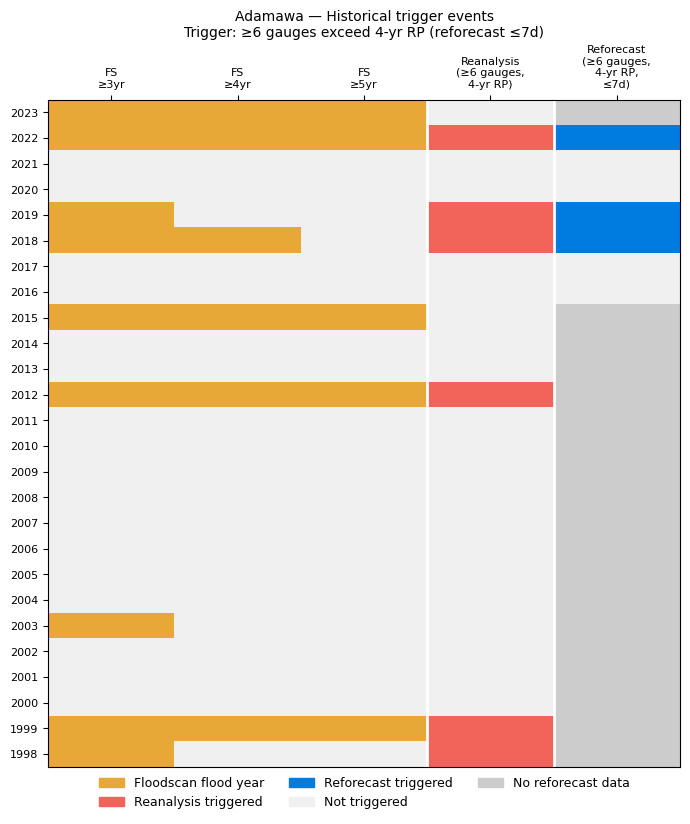

In [32]:
all_years = list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))

# Build trigger matrix
df_fs_cols = df_fs_ann.set_index("year")[[f"flood_{rp}yr" for rp in FS_RP_LEVELS]]

trig_matrix = pd.DataFrame(index=all_years)
trig_matrix.index.name = "year"

for rp in FS_RP_LEVELS:
    trig_matrix[f"fs_{rp}yr"] = df_fs_cols[f"flood_{rp}yr"]

trig_matrix["reanalysis"] = ra_triggered

# Reforecast: NaN for years without complete data
trig_matrix["reforecast"] = np.nan
trig_matrix.loc[trig_matrix.index.isin(rf_complete_years), "reforecast"] = rf_triggered

trig_matrix = trig_matrix.sort_index(ascending=False)

# ── Color encoding ─────────────────────────────────────────────────────────────
# 0=no data (#CCCCCC), 1=not triggered (#F0F0F0),
# 2=reforecast triggered (#007CE0), 3=reanalysis triggered (#F2645A),
# 4=Floodscan flood year (#E8A838)
plot_data = trig_matrix.copy()

for col in [f"fs_{rp}yr" for rp in FS_RP_LEVELS]:
    plot_data[col] = plot_data[col].map({0: 1, 1: 4}).fillna(0).astype(int)

plot_data["reanalysis"] = plot_data["reanalysis"].map({0: 1, 1: 3}).fillna(0).astype(int)
plot_data["reforecast"] = plot_data["reforecast"].map({0.0: 1, 1.0: 2}).fillna(0).astype(int)

# ── Plot ───────────────────────────────────────────────────────────────────────
col_order  = [f"fs_{rp}yr" for rp in FS_RP_LEVELS] + ["reanalysis", "reforecast"]
col_labels = [f"FS\n≥{rp}yr" for rp in FS_RP_LEVELS] + [
    f"Reanalysis\n(≥{N_GAUGES} gauges,\n{RP_THRESH}-yr RP)",
    f"Reforecast\n(≥{N_GAUGES} gauges,\n{RP_THRESH}-yr RP,\n≤{MAX_LEAD_TIME}d)",
]

cmap = mcolors.ListedColormap(["#CCCCCC", "#F0F0F0", "#007CE0", "#F2645A", "#E8A838"])
norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

n_rows = len(trig_matrix)
n_cols = len(col_order)
fig, ax = plt.subplots(figsize=(max(6, n_cols * 1.4), max(6, n_rows * 0.32)))

ax.imshow(plot_data[col_order].values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(n_cols))
ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(trig_matrix.index, fontsize=8)
ax.xaxis.tick_top()

# Separator between Floodscan group and trigger columns
ax.axvline(x=len(FS_RP_LEVELS) - 0.5, color="white", linewidth=2)
# Separator between reanalysis and reforecast
ax.axvline(x=len(FS_RP_LEVELS) + 0.5, color="white", linewidth=2)

ax.set_title(
    f"{STATE} — Historical trigger events\n"
    f"Trigger: ≥{N_GAUGES} gauges exceed {RP_THRESH}-yr RP (reforecast ≤{MAX_LEAD_TIME}d)",
    fontsize=10, pad=45,
)

legend_items = [
    mpatches.Patch(color="#E8A838", label="Floodscan flood year"),
    mpatches.Patch(color="#F2645A", label="Reanalysis triggered"),
    mpatches.Patch(color="#007CE0", label="Reforecast triggered"),
    mpatches.Patch(color="#F0F0F0", label="Not triggered"),
    mpatches.Patch(color="#CCCCCC", label="No reforecast data"),
]
ax.legend(handles=legend_items, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          ncol=3, frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"06_trigger_events_rp{RP_THRESH}_n{N_GAUGES}_lt{MAX_LEAD_TIME}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## Per-Gauge Contribution to Trigger Events

Gauge contributions across 6 reanalysis trigger year(s):



,threshold_m3s,n_triggers_contributed
hybas_1120840690,142.7,4
hybas_1120843610,1101.5,5
hybas_1120845060,1102.2,6
hybas_1120848550,1106.0,6
hybas_1121970280,1110.1,6
hybas_1120842990,1110.8,5
hybas_1120840700,1112.6,6
hybas_1120849600,1113.7,6
hybas_1120842550,1114.0,6
hybas_1120840560,1117.1,6


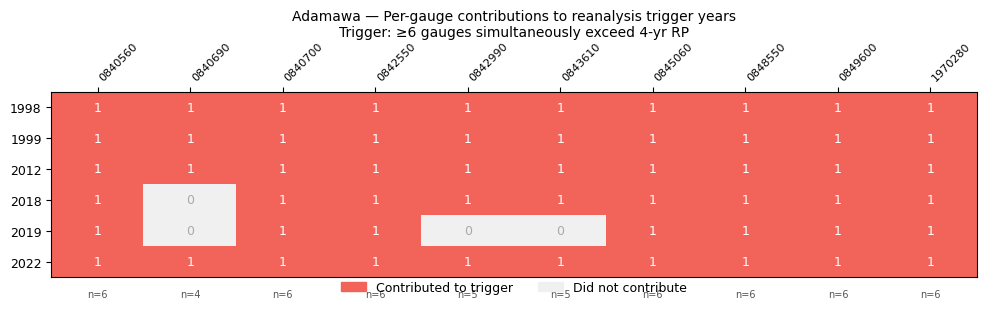

In [33]:
# For each reanalysis trigger year, identify which gauges were active on the
# triggering day(s) — i.e. the days where >= N_GAUGES exceeded simultaneously.
ra_trigger_years = sorted(ra_triggered[ra_triggered == 1].index.tolist())

df_pivot = df_ra_check.pivot_table(
    index=["year", "date"], columns="gauge_id", values="exceeded", fill_value=0
)

rows = []
for year in ra_trigger_years:
    if year not in df_pivot.index.get_level_values("year"):
        continue
    year_slice = df_pivot.xs(year, level="year")
    daily_n = year_slice.sum(axis=1)
    trigger_days = year_slice[daily_n >= N_GAUGES]
    participated = trigger_days.any(axis=0)
    for gauge in grrr_ids:
        rows.append({
            "year": year,
            "gauge_id": gauge,
            "contributed": int(participated.get(gauge, 0)),
        })

df_contrib = pd.DataFrame(rows)
pivot_contrib = df_contrib.pivot(index="year", columns="gauge_id", values="contributed")

gauge_contrib_count = pivot_contrib.sum().rename("n_triggers_contributed")

# Summary table: threshold + contribution count side by side
summary = thresh_series.round(1).rename("threshold_m3s").to_frame()
summary = summary.join(gauge_contrib_count)
summary["n_triggers_contributed"] = summary["n_triggers_contributed"].fillna(0).astype(int)
print(f"Gauge contributions across {len(ra_trigger_years)} reanalysis trigger year(s):\n")
display(summary.sort_values("threshold_m3s"))

# Heatmap: rows = trigger years, cols = gauges
short_labels = [g[-7:] for g in pivot_contrib.columns]

fig, ax = plt.subplots(
    figsize=(max(8, len(grrr_ids) * 1.0), max(3, len(ra_trigger_years) * 0.55))
)

cmap2 = mcolors.ListedColormap(["#F0F0F0", "#F2645A"])
norm2 = mcolors.BoundaryNorm([0, 0.5, 1.5], 2)

ax.imshow(pivot_contrib.values, cmap=cmap2, norm=norm2, aspect="auto")

ax.set_xticks(range(len(pivot_contrib.columns)))
ax.set_xticklabels(short_labels, rotation=45, ha="left", fontsize=8)
ax.set_yticks(range(len(ra_trigger_years)))
ax.set_yticklabels(ra_trigger_years, fontsize=9)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

for i in range(len(ra_trigger_years)):
    for j in range(len(pivot_contrib.columns)):
        val = pivot_contrib.iloc[i, j]
        ax.text(j, i, str(int(val)), ha="center", va="center", fontsize=9,
                color="white" if val else "#AAAAAA")

# Contribution counts below the heatmap
count_labels = [
    f"n={int(gauge_contrib_count.get(g, 0))}" for g in pivot_contrib.columns
]
for j, label in enumerate(count_labels):
    ax.text(j, len(ra_trigger_years) - 0.5 + 0.7, label,
            ha="center", va="bottom", fontsize=7, color="#555555")

ax.set_title(
    f"{STATE} — Per-gauge contributions to reanalysis trigger years\n"
    f"Trigger: ≥{N_GAUGES} gauges simultaneously exceed {RP_THRESH}-yr RP",
    fontsize=10, pad=40,
)

legend_items = [
    mpatches.Patch(color="#F2645A", label="Contributed to trigger"),
    mpatches.Patch(color="#F0F0F0", label="Did not contribute"),
]
ax.legend(handles=legend_items, loc="lower center", bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"06_gauge_contributions_rp{RP_THRESH}_n{N_GAUGES}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()